# 1 Linear Regression


##  Model Expression

The model for linear regression is defined as:

$y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$


##  Loss Function

We measure the performance of the model using the Mean Squared Error (MSE) between the predicted values and the true values:

$L(W, b) = \frac{1}{m} \sum_{i=1}^{m} \bigl[y^{(i)} - \hat{y}^{(i)}\bigr]^2 = \frac{1}{m} \sum_{i=1}^{m} \bigl[y^{(i)} - \bigl(w_1 x_1^{(i)} + w_2 x_2^{(i)} + \dots + w_n x_n^{(i)} + b\bigr)\bigr]^2$

> **Note:**  
> - $y^{(i)}$ is the true value of the $i$-th sample.  
> - $\hat{y}^{(i)}$ is the predicted value.  
> - $m$ is the number of samples.  
> - $n$ is the number of features.


## Matrix Form

### Model

$\mathbf{Y} = \mathbf{X}\,\mathbf{W}$

### Loss

$L(W) = \frac{1}{m} \lVert \mathbf{Y} - \mathbf{X}\mathbf{W} \rVert^2$


## Incorporating the Bias Term

1. **Augment** $\mathbf{X}$  
   Add a column of ones to $\mathbf{X}$:  
   $\mathbf{X} = [\,x_1,\;x_2,\;\dots,\;x_k,\;1\,]$

2. **Extend** $\mathbf{W}$  
   Add $w_{k+1}$ to replace $b$:  
   $\mathbf{W} = \begin{bmatrix}
     w_1 \\[4pt]
     w_2 \\[4pt]
     \vdots \\[4pt]
     w_k \\[4pt]
     w_{k+1}
   \end{bmatrix}$

   Then  
   $\mathbf{X}\mathbf{W} = w_1 x_1 + \dots + w_k x_k + w_{k+1} = w_1 x_1 + \dots + w_k x_k + b$  
   where $b = w_{k+1}$.



## Analytical Solution (Normal Equation)

The closed‐form solution for the weight vector $W$ that minimizes the MSE is given by the normal equation:

$$
W = 
\begin{bmatrix}
w_1 \\[4pt]
w_2 \\[4pt]
\vdots \\[4pt]
w_n \\[4pt]
b
\end{bmatrix}
= \bigl(\mathbf{X}^T \mathbf{X}\bigr)^{-1} \mathbf{X}^T \mathbf{Y}
$$

- Here, $\mathbf{X}$ is the augmented design matrix (including the column of ones),  
- $\mathbf{Y}$ is the vector of target values,  
- and $\bigl(\mathbf{X}^T \mathbf{X}\bigr)^{-1} \mathbf{X}^T$ is the Moore–Penrose pseudo‐inverse when $\mathbf{X}^T \mathbf{X}$ is invertible.

In [3]:
import numpy as np

# input data X
X = np.array([
    [0, 2],
    [1, 1],
    [2, 3],
    [3, 2],
    [4, 5],
    [5, 2]
])

# output data y
y = np.array([8, 7, 15, 14, 25, 18])

# add a column of ones to X for the bias term
X_aug = np.insert(X, X.shape[1], 1, axis=1)

print(f'X_aug:{X_aug}')

# compute weights using the normal equation: w = (X^T X)^{-1} X^T y
w = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y

print("Model parameters w:", w)


X_aug:[[0 2 1]
 [1 1 1]
 [2 3 1]
 [3 2 1]
 [4 5 1]
 [5 2 1]]
Model parameters w: [2. 3. 2.]


In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np

# input data X
X = np.array([
    [0, 2],
    [1, 1],
    [2, 3],
    [3, 2],
    [4, 5],
    [5, 2]
])

# output data y
y = np.array([8, 7, 15, 14, 25, 18])

# initialize the linear regression model
reg = LinearRegression()

# train the model
reg.fit(X, y)

# print the learned parameters
print("Model coefficients:", reg.coef_)
print("Model intercept:", reg.intercept_)


Model coefficients: [2. 3.]
Model intercept: 2.0


# 2 Gradient Descent

## Gradient Descent Optimization

To minimize the MSE loss, we iteratively update the weight vector $W$ using gradient descent:

1. **Compute the gradient**  
   The gradient of the loss w.r.t.\ $W$ is
   $$
   \nabla_{W} L(W)
   = \frac{\partial}{\partial W}
     \Bigl[\frac{1}{m}\|Y - XW\|^2\Bigr]
   = \frac{2}{m}\,X^{T}\bigl(XW - Y\bigr)
   $$

2. **Update rule**  
   At each iteration $t$, update
   $$
   W^{(t+1)}
   = W^{(t)} \;-\; \alpha \,\nabla_{W} L\bigl(W^{(t)}\bigr)
   = W^{(t)} \;-\; \alpha\,\frac{2}{m}\,X^{T}\bigl(XW^{(t)} - Y\bigr)
   $$
   where $\alpha$ is the learning rate.

3. **Element‐wise form**  
   For each component $w_{j}$ of $W$,  
   $$
   w_{j}^{(t+1)}
   = w_{j}^{(t)} - \alpha \,\frac{2}{m}
     \sum_{i=1}^{m}\Bigl(\hat y^{(i)} - y^{(i)}\Bigr)\,x_{j}^{(i)}
   $$
   and for the bias term $b$ (if separated),
   $$
   b^{(t+1)}
   = b^{(t)} - \alpha \,\frac{2}{m}
     \sum_{i=1}^{m}\Bigl(\hat y^{(i)} - y^{(i)}\Bigr).
   $$

**Usage notes:**  
- Initialize $W^{(0)}$ (and $b^{(0)}$) randomly or to zeros.  
- Choose a suitable $\alpha$; too large may diverge, too small converges slowly.  
- Stop when $\|W^{(t+1)} - W^{(t)}\|$ is below a threshold or after a fixed number of iterations.


In [6]:
"""
This script demonstrates gradient descent to find the minimum of 
y = (x1 - 2)**2 + (x2 - 3)**2.
"""

# Initialize variables
x1, x2 = 0.0, 0.0

# Hyperparameters
learning_rate = 0.1
max_iters = 100
tolerance = 1e-3

for i in range(1, max_iters + 1):
    # Compute gradients
    dx1 = 2 * (x1 - 2)    # ∂y/∂x1
    dx2 = 2 * (x2 - 3)    # ∂y/∂x2

    # Update variables along negative gradient
    x1 -= learning_rate * dx1
    x2 -= learning_rate * dx2

    # Compute current loss
    y = (x1 - 2)**2 + (x2 - 3)**2

    print(f"Iteration {i}: x1 = {x1:.4f}, x2 = {x2:.4f}, y = {y:.6f}")

    # Check termination condition
    if abs(dx1) < tolerance and abs(dx2) < tolerance:
        print("Convergence reached.")
        break


Iteration 1: x1 = 0.4000, x2 = 0.6000, y = 8.320000
Iteration 2: x1 = 0.7200, x2 = 1.0800, y = 5.324800
Iteration 3: x1 = 0.9760, x2 = 1.4640, y = 3.407872
Iteration 4: x1 = 1.1808, x2 = 1.7712, y = 2.181038
Iteration 5: x1 = 1.3446, x2 = 2.0170, y = 1.395864
Iteration 6: x1 = 1.4757, x2 = 2.2136, y = 0.893353
Iteration 7: x1 = 1.5806, x2 = 2.3709, y = 0.571746
Iteration 8: x1 = 1.6645, x2 = 2.4967, y = 0.365917
Iteration 9: x1 = 1.7316, x2 = 2.5973, y = 0.234187
Iteration 10: x1 = 1.7853, x2 = 2.6779, y = 0.149880
Iteration 11: x1 = 1.8282, x2 = 2.7423, y = 0.095923
Iteration 12: x1 = 1.8626, x2 = 2.7938, y = 0.061391
Iteration 13: x1 = 1.8900, x2 = 2.8351, y = 0.039290
Iteration 14: x1 = 1.9120, x2 = 2.8681, y = 0.025146
Iteration 15: x1 = 1.9296, x2 = 2.8944, y = 0.016093
Iteration 16: x1 = 1.9437, x2 = 2.9156, y = 0.010300
Iteration 17: x1 = 1.9550, x2 = 2.9324, y = 0.006592
Iteration 18: x1 = 1.9640, x2 = 2.9460, y = 0.004219
Iteration 19: x1 = 1.9712, x2 = 2.9568, y = 0.002700
It

# 3 Logistic Regression


## Model Expression

The model for binary logistic regression predicts the probability that $y=1$ given input $x$:

$p(y=1 \mid x) = \sigma\bigl(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b\bigr) = \frac{1}{1 + e^{-\bigl(w_1 x_1 + \dots + w_n x_n + b\bigr)}}$

The predicted label is

$\hat y = 
\begin{cases}
1, & \sigma(w^T x + b) \ge 0.5,\\
0, & \text{otherwise.}
\end{cases}$


## Loss Function (Binary Cross‐Entropy)

For a single sample $(x^{(i)}, y^{(i)})$, the negative log‐likelihood (cross‐entropy) loss is

$\ell^{(i)} = -\bigl[y^{(i)} \log \hat p^{(i)} + (1 - y^{(i)}) \log\bigl(1 - \hat p^{(i)}\bigr)\bigr]$

where $\hat p^{(i)} = \sigma(w^T x^{(i)} + b)$.

Over the whole dataset of $m$ samples, the average loss is

$L(W,b) = \frac{1}{m}\sum_{i=1}^{m} \ell^{(i)}
= -\frac{1}{m} \sum_{i=1}^{m} \bigl[y^{(i)} \log \hat p^{(i)} + (1 - y^{(i)}) \log\bigl(1 - \hat p^{(i)}\bigr)\bigr]$


## Matrix Form

Let $X \in \mathbb{R}^{m\times (n+1)}$ be the design matrix with a column of ones for the bias, and $W \in \mathbb{R}^{n+1}$ the parameter vector. Define

$\hat{\mathbf{p}} = \sigma(X\,W)$

where $\sigma$ is applied element‐wise. Then

$L(W) = -\frac{1}{m} \bigl[y^T \log(\hat{\mathbf{p}}) + (1 - y)^T \log\bigl(1 - \hat{\mathbf{p}}\bigr)\bigr]$


## Gradient Descent Update

The gradient of $L$ w.r.t.\ $W$ is

$\nabla_W L = \frac{1}{m} \,X^T\bigl(\hat{\mathbf{p}} - y\bigr)$

At each iteration $t$, update

$W^{(t+1)} = W^{(t)} - \alpha\,\nabla_W L
= W^{(t)} - \alpha\,\frac{1}{m}\,X^T\bigl(\hat{\mathbf{p}}^{(t)} - y\bigr)$

where $\alpha$ is the learning rate.



In [7]:
import numpy as np
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data[:, 4:8]  # use 4 features as an example
y = data.target        # binary labels (0 or 1)

# Add a bias term (column of ones) to X
X_aug = np.hstack([X, np.ones((X.shape[0], 1))])

# Initialize weights randomly
np.random.seed(888)
w = np.random.rand(X_aug.shape[1])

# Hyperparameters
learning_rate = 0.01
num_iters = 10000

# Gradient descent loop
for i in range(num_iters):
    # Compute the linear combination
    z = X_aug @ w
    
    # Apply sigmoid to get predicted probabilities
    p = 1 / (1 + np.exp(-z))
    
    # Compute the gradient of the negative log‐likelihood
    grad = (X_aug.T @ (p - y)) / y.shape[0]
    
    # Update weights along the negative gradient
    w -= learning_rate * grad

# Final predicted probabilities
p_final = 1 / (1 + np.exp(-X_aug @ w))

print("Learned weights:", w)


Learned weights: [ 0.66230512 -1.22802507 -2.01730432 -0.45187266  0.77442548]


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

# ---- Load data ----
data = load_breast_cancer()        # load the breast cancer dataset
X = data.data[:, 4:8]              # use features 4–7 for modeling
y = data.target                    # binary labels (0 or 1)

# ---- Train logistic regression ----
clf = LogisticRegression(random_state=0)
clf.fit(X, y)

# ---- Print results ----
print("Model coefficients:", clf.coef_)      # learned feature weights (w₁…w₄)
print("Model intercept:", clf.intercept_)    # learned bias term (b)

Model coefficients: [[-0.52968191 -3.48245857 -6.89159253 -4.38088002]]
Model intercept: [1.80082853]


# 4 Decision Tree

# CART Trees (Classification And Regression Trees) Overview

CART, introduced by Breiman et al. (1984), is a binary tree algorithm for both **classification** and **regression**. It recursively partitions the data by choosing, at each node, a feature and threshold that maximize some measure of purity (classification) or minimize variance (regression).


## 1. Binary Splitting

At a node with sample set $S$, choose feature $j$ and threshold $t$ to split into  
$$
S_{\text{left}} = \{\,x : x_j \le t\},\quad
S_{\text{right}} = \{\,x : x_j > t\}.
$$


## 2. Optimal Split Criterion

### 2.1 Classification (Gini Impurity)

- **Node impurity**  
  For $K$ classes with proportions $p_k$ in $S$,  
  $$
  \mathrm{Gini}(S) \;=\; 1 - \sum_{k=1}^{K} p_k^2.
  $$

- **Weighted impurity after split**  
  $$
  \mathrm{Gini}_{\text{split}}(j,t)
  = \frac{|S_{\text{left}}|}{|S|}\,\mathrm{Gini}(S_{\text{left}})
  + \frac{|S_{\text{right}}|}{|S|}\,\mathrm{Gini}(S_{\text{right}}).
  $$

- **Impurity reduction**  
  $$
  \Delta \mathrm{Gini}(j,t)
  = \mathrm{Gini}(S) \;-\; \mathrm{Gini}_{\text{split}}(j,t).
  $$

The best split $(j^*,t^*)$ maximizes $\Delta \mathrm{Gini}(j,t)$.

### 2.2 Regression (Variance Reduction / MSE)

- **Node variance (MSE)**  
  Let $\bar y_S = \frac{1}{|S|}\sum_{i\in S} y_i$.  
  $$
  Q(S)
  = \frac{1}{|S|}\sum_{i\in S}\bigl(y_i - \bar y_S\bigr)^2.
  $$

- **Weighted variance after split**  
  $$
  Q_{\text{split}}(j,t)
  = \frac{|S_{\text{left}}|}{|S|}Q(S_{\text{left}})
  + \frac{|S_{\text{right}}|}{|S|}Q(S_{\text{right}}).
  $$

- **Variance reduction**  
  $$
  \Delta Q(j,t)
  = Q(S) - Q_{\text{split}}(j,t).
  $$

Choose $(j^*,t^*)$ that maximizes $\Delta Q(j,t)$.


## 3. Recursive Tree Growth

1. Start with root node containing all training samples.  
2. At each non-leaf node:
   - Evaluate all $(j,t)$ candidate splits.
   - Select $(j^*,t^*)$ that maximizes impurity/variance reduction.
   - Partition $S$ into $S_{\text{left}}$ and $S_{\text{right}}$.  
3. Stop when a stopping condition is met, e.g.:
   - Maximum depth reached.
   - Minimum samples per leaf.
   - Impurity or variance below a threshold.


## 4. Cost-Complexity Pruning

To avoid overfitting, CART applies cost-complexity pruning. For a subtree $T$ and pruning parameter $\alpha\ge0$, define the cost

$$
R_{\alpha}(T)
= \sum_{m=1}^{|T|} \frac{N_m}{N}\,Q_m
\;+\;\alpha\,|T|,
$$

- $|T|$: number of leaves in $T$.  
- $N_m$: number of samples in leaf $m$.  
- $Q_m$: impurity (classification) or variance (regression) at leaf $m$.  
- $N$: total number of samples.

Select the subtree that minimizes $R_{\alpha}(T)$ as $\alpha$ varies.



In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Data preparation
iris = load_iris()
clf = DecisionTreeClassifier(min_samples_leaf=15, random_state=0)
clf = clf.fit(iris.data, iris.target)
test_x = iris.data[[0], :]
pred_target = clf.predict(test_x)

# Print model structure
print("\n=== Model Structure ===")
print("Left child indices:     ", clf.tree_.children_left)
print("Right child indices:    ", clf.tree_.children_right)
print("Split feature indices:  ", clf.tree_.feature) # -2（等同于常量 sklearn.tree._tree.TREE_UNDEFINED）表示这是一个叶子节点，没有进一步的分裂。

print("Split thresholds:       ", np.round(clf.tree_.threshold, 2))
node_classes = [clf.classes_[np.argmax(value)] for value in clf.tree_.value]
print("Class at each node:     ", node_classes)

# Print prediction
print("\n=== Prediction ===")
print("Test sample:            ", test_x)
print("Predicted class:        ", pred_target)


=== Model Structure ===
Left child indices:      [ 1 -1  3  4 -1 -1  7 -1 -1]
Right child indices:     [ 2 -1  6  5 -1 -1  8 -1 -1]
Split feature indices:   [ 3 -2  3  2 -2 -2  2 -2 -2]
Split thresholds:        [ 0.8  -2.    1.75  4.45 -2.   -2.    5.25 -2.   -2.  ]
Class at each node:      [0, 0, 1, 1, 1, 1, 2, 2, 2]

=== Prediction ===
Test sample:             [[5.1 3.5 1.4 0.2]]
Predicted class:         [0]


## ID3 Algorithm

1. **Basic Idea**  
   ID3 (Iterative Dichotomiser 3) builds a classification tree by recursively selecting the feature that maximizes **information gain**.

2. **Entropy**  
   For a node with sample set $S$ and $K$ classes, let $p_k$ be the fraction of samples in class $k$.  
   $$
   H(S) \;=\; -\sum_{k=1}^{K} p_k \,\log_2 p_k
   $$

3. **Information Gain**  
   For feature $A$ with value set $\mathcal{V}(A)$, splitting $S$ into subsets $S_v = \{x\in S: A(x)=v\}$, the gain is  
   $$
   \mathrm{Gain}(S,A)
   = H(S)
     - \sum_{v\in \mathcal{V}(A)} \frac{|S_v|}{|S|}\,H(S_v)
   $$  
   Choose the feature $A^*$ with maximum $\mathrm{Gain}(S,A)$.

4. **Recursive Splitting**  
   - Stop when all samples in $S$ share the same class or no features remain.  
   - Otherwise, split on $A^*$ and recurse on each child.

5. **Pros & Cons**  
   - **Pros:** Simple, fast to compute.  
   - **Cons:** Biased toward multi‐valued features, no built-in handling of continuous attributes or missing values, no pruning.


## C4.5 Algorithm

1. **Enhancements over ID3**  
   - Supports **continuous** and **categorical** attributes.  
   - Uses **gain ratio** instead of raw information gain.  
   - Implements **pruning** and handles **missing values**.

2. **Split Information**  
   For feature $A$,  
   $$
   \mathrm{SI}(S,A)
   = -\sum_{v\in\mathcal{V}(A)} \frac{|S_v|}{|S|}\,\log_2\frac{|S_v|}{|S|}
   $$

3. **Gain Ratio**  
   $$
   \mathrm{GainRatio}(S,A)
   = \frac{\mathrm{Gain}(S,A)}{\mathrm{SI}(S,A)}
   $$  
   Select the feature maximizing gain ratio to avoid bias toward many‐valued attributes.

4. **Continuous Attribute Handling**  
   - Sort samples by $A$, consider midpoints between adjacent values as candidate thresholds $t$.  
   - Treat split as binary: $A \le t$ vs.\ $A > t$.

5. **Pruning**  
   - Builds the full tree, then performs **error‐based pruning** using confidence intervals on error estimates.  
   - Prunes subtrees that do not improve estimated generalization.

6. **Missing Values**  
   - Distributes a sample with missing $A$ across child nodes proportionally to observed frequencies.  
   - Adjusts weight in gain and split calculations accordingly.




# Esemble Tree

## GBDT

Gradient Boosting Decision Tree (GBDT) is an ensemble algorithm built on decision‐tree base learners. It uses a **sequential additive** model: at each iteration you train a new tree whose sole purpose is to **fit the residuals** (errors) of the ensemble so far (i.e. reduce the previous step’s error). By repeatedly updating the “training data” (or the data weights) according to the last round’s residuals and then fitting a fresh weak learner to those residuals, GBDT gradually turns a series of weak learners into a strong learner. The final prediction is simply the **sum** of all individual tree outputs.


## XGBoost


Here’s the comparison in English, formatted as a Markdown table:

| Aspect                        | Classic GBDT                                                   | XGBoost                                                                                                                                 |
| ----------------------------- | -------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **Objective Function**        | Minimize differentiable loss $L$                               | $\displaystyle \mathcal L = \sum_i L(y_i,\hat y_i) \;+\; \sum_k \Omega(f_k)$, where $\Omega(f)=\gamma\,T + \tfrac12\lambda\sum_j w_j^2$ |
| **Taylor Expansion Order**    | First-order only (gradient)                                    | Second-order (gradient $g_i$ + Hessian $h_i$) to compute split gains                                                                    |
| **Regularization**            | Implicit via shrinkage (learning rate) and limiting tree depth | Explicit L1/L2 on leaf weights plus a leaf-count penalty $\gamma$                                                                                                                                                                    
| **Missing-Value Handling**    | Requires pre-imputation or manual direction tricks             | Built-in learning of default directions for missing values                                                                              |
| **Pruning / Tree Control**    | Controlled by `max_depth`, `min_samples_leaf`                  | Supports `max_depth`, `max_leaves`, `colsample_bytree`, `subsample`, etc.                                                               |

*In a nutshell:*

* **GBDT** is the core idea of sequentially fitting trees to the gradient of the loss.
* **XGBoost** builds on GBDT by adding second-order optimization, explicit regularization, and extensive engineering optimizations for speed and scalability.

## AdaBoost

**Adaptive Boosting (AdaBoost)** is a sequential ensemble method that combines multiple “weak” learners into a single “strong” classifier by re‐weighting training examples.

The core of AdaBoost boils down to two complementary mechanisms:

1. **Iterative Sample Reweighting**
   After each weak learner is trained, the algorithm increases the weights of the examples it got wrong and decreases the weights of those it got right. This forces the next weak learner to focus on the “hard” cases.

2. **Weighted Combination of Weak Learners**
   Each weak learner is assigned a weight

   $$
     \alpha_m = \tfrac12\ln\frac{1 - \varepsilon_m}{\varepsilon_m}
   $$

   based on its training error $\varepsilon_m$. The final strong classifier is the sign of the weighted sum of all weak learners, which is equivalent to minimizing the exponential loss

   $$
     L = \sum_{i=1}^N \exp\bigl(-y_i\,F(x_i)\bigr).
   $$


## Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees and aggregates their predictions to improve generalization and reduce overfitting.

**Core Mechanisms**  
1. **Bootstrap Aggregation (Bagging)**  
   - Each tree $$h_m(x)$$ is trained on a random bootstrap sample (with replacement) of the original dataset.  
2. **Random Feature Subspacing**  
   - At each split in a tree, only a random subset of features is considered, introducing further diversity among trees.  
3. **Aggregation of Predictions**  
   - **Regression:**  
     $$
       \hat y = \frac{1}{M}\sum_{m=1}^M h_m(x).
     $$  
   - **Classification:**  
     $$
       \hat y = \underset{c}{\arg\max}\;\sum_{m=1}^M \mathbf{1}\{h_m(x)=c\}.
     $$

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the ensemble models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=iris.target_names), end="\n" + "-"*60 + "\n")


Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------------------------------------------------------------
AdaBoost Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.89      0.89         9
   virginica       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

------------------------------------------------------------
Gradient Boosting Accuracy: 1.0000
              precision 

/Users/honglinqian/Anaconda/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:48:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


# 5 k-means



## K-means Algorithm Steps

1. **Choose the number of clusters** \(K\).  
2. **Initialize** \(K\) **cluster centroids** .  
3. **Assign each sample** to the nearest centroid.  
   - Compute the distance from each point to all centroids, then assign it to the closest one.  
4. **Update each centroid** to the mean of all points assigned to that cluster.  
5. **Repeat** steps 3 and 4 until convergence:  
   - Stop when centroids move less than a small threshold or a maximum number of iterations is reached.  
6. **Output** the final \(K\) cluster centroids (and cluster assignments).

## 1. Selecting \(K\)  
Based on domain knowledge, estimate the approximate number of clusters \(K\).  
- If you’re unsure, you can start with about 5 clusters.  
  - If the true number of clusters is fewer than 5, you can merge them later.  
  - If there are more than 5, you’ll at least capture some structure and can increase \(K\) afterwards.

## 2. Initializing Cluster Centroids  
A common method is to randomly pick \(K\) samples from the data as the initial centroids.

## 3. Distance Metrics  
The most frequently used distance metrics are Euclidean distance, Manhattan distance, and Cosine distance.

**Euclidean distance** between two points \(x,y\in\mathbb{R}^n\):  
$$
d_{\mathrm{Euclid}}(x, y)
= \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
= \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots + (x_n - y_n)^2}.
$$

**Manhattan distance**:  
$$
d_{\mathrm{Manhattan}}(x, y)
= \sum_{i=1}^n \lvert x_i - y_i \rvert.
$$

**Cosine distance**:  
$$
d_{\mathrm{cos}}(x, y)
= 1 - \frac{\sum_{i=1}^n x_i\,y_i}{\sqrt{\sum_{i=1}^n x_i^2}\;\sqrt{\sum_{i=1}^n y_i^2}}.
$$

## 4. Loss Function  
K-means minimizes the within-cluster sum of squared errors (WCSS):  
$$
J \;=\; \sum_{k=1}^K \;\sum_{x_i \in C_k} \big\lVert x_i - \mu_k\big\rVert^2,
$$  
where $C_k$ is the set of points in cluster $k$ and  
$$
\mu_k = \frac{1}{|C_k|}\sum_{x_i\in C_k}x_i
$$  
is the centroid of cluster \(k\).

## 5. Advantages and Disadvantages

### Advantages  
- **Simplicity & Speed**  
  - Algorithm is easy to implement; each iteration is \(O(NK)\).  
- **Scalability**  
  - Works well on large datasets.  
- **Interpretability**  
  - Final centroids directly represent cluster “centers.”

### Disadvantages  
- **Need to specify \(K\) in advance**  
  - Choosing the wrong \(K\) can lead to poor clustering.  
- **Sensitive to initialization**  
  - Random starts may converge to different local minima (mitigated by K-means++).  
- **Assumes spherical clusters**  
  - Performs poorly on non-convex or different-density clusters.  
- **Sensitive to outliers/noise**  
  - Squared-distance loss exaggerates the effect of distant points.  


/Users/honglinqian/Anaconda/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



Cluster centers:
 [[ 2.82658229  4.81643505]
 [-6.32786406 -8.29385949]
 [ 0.16708771 -5.5095078 ]
 [-6.33134096  5.2392252 ]
 [ 5.58979223 -9.47728671]]


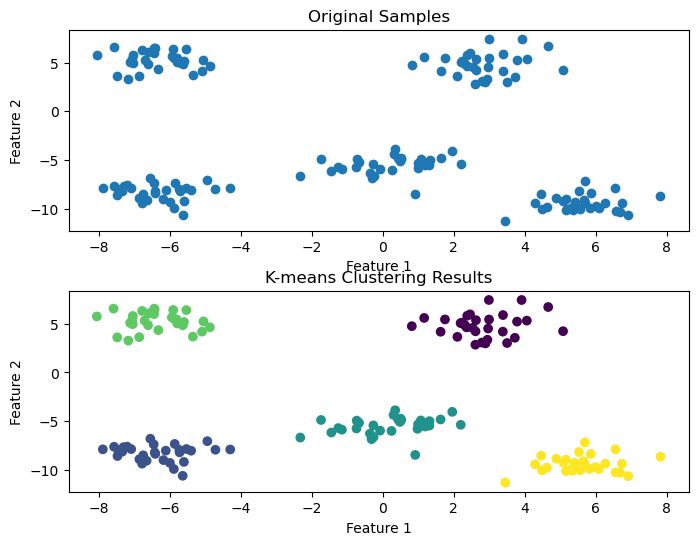

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# ------------- Generate synthetic data -------------
X, y_true = make_blobs(n_samples=150, centers=5, random_state=10)

# ----------- Train K-means and predict -------------
kmeans = KMeans(n_clusters=5, max_iter=300, random_state=0)  # initialize K-means
kmeans.fit(X)                                               # fit to data
y_pred = kmeans.predict(X)                                  # predict cluster labels

# -------------- Print cluster centers ---------------
print('\nCluster centers:\n', kmeans.cluster_centers_)

# --------- Plot original vs. clustered samples ---------
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# Original data
axes[0].set_title('Original Samples')
axes[0].scatter(X[:, 0], X[:, 1])
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Clustered data
axes[1].set_title('K-means Clustering Results')
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.show()

centers: [[-7.48104159  3.60176388]
 [-6.5489818  -6.82113941]
 [ 4.65804929  6.7208918 ]
 [-5.63627361  4.83785283]
 [-4.71547923 -7.95359832]]


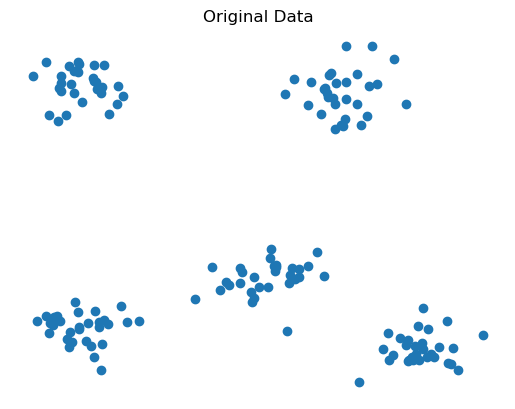

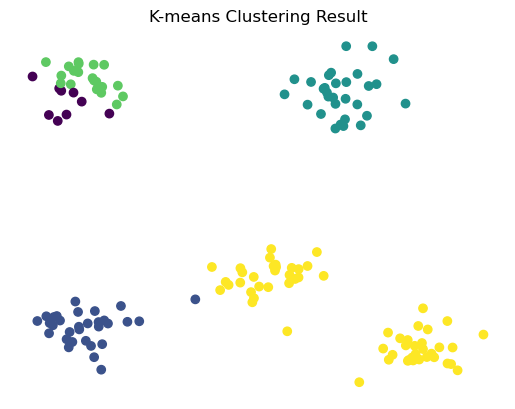

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ------ Generate data -----------
X, y = make_blobs(n_samples=150, centers=5, random_state=10)
n_samples = X.shape[0]

# ------ Initialization -----------
k = 5  # number of clusters
initial_indices = np.random.randint(0, n_samples, k)  # randomly pick k samples as initial centers
centers = X[initial_indices, :]  # initial cluster centers
print(f'centers: {centers}')


# ------ K-means clustering process -----------
cluster_assignments = np.zeros(n_samples, dtype=int)  # array to hold each sample's cluster index

for iteration in range(20):  # iterate 20 times
    # 1) Assign each sample to the nearest center
    for i in range(n_samples):
        distances = np.sum((centers - X[i, :])**2, axis=1) # arr.sum(axis=1) 是 按行求和，即对每一行的所有列求和，结果是一维数组，长度等于行数。
        cluster_assignments[i] = np.argmin(distances)
    
    # 2) Update each center to be the mean of assigned samples
    for j in range(k):
        centers[j] = X[cluster_assignments == j, :].mean(axis=0)
    
# Plot original data
plt.figure()
plt.title('Original Data')
plt.scatter(X[:, 0], X[:, 1])
plt.axis('off')
plt.show()

# Plot clustering result
plt.figure()
plt.title('K-means Clustering Result')
plt.scatter(X[:, 0], X[:, 1], c=cluster_assignments)
plt.axis('off')
plt.show()


# 6 Metric


Assume the confusion matrix values are:  
- True Positives (TP)  
- False Positives (FP)  
- True Negatives (TN)  
- False Negatives (FN)  

|                   | Predicted Positive | Predicted Negative |
|-------------------|--------------------|--------------------|
| **Actual Positive** | TP                 | FN                 |
| **Actual Negative** | FP                 | TN                 |


## (1) Basic Statistic Metric

## 1. True Positive Rate (TPR)  
Also called **Sensitivity** or **Recall**, the proportion of actual positives correctly identified:  
$$
\mathrm{TPR}
\;=\;
\frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}.
$$

## 2. False Negative Rate (FNR)  
The proportion of actual positives incorrectly labeled negative:  
$$
\mathrm{FNR}
\;=\;
\frac{\mathrm{FN}}{\mathrm{TP} + \mathrm{FN}}
\;=\;
1 - \mathrm{TPR}.
$$

## 3. True Negative Rate (TNR)  
Also called **Specificity**, the proportion of actual negatives correctly identified:  
$$
\mathrm{TNR}
\;=\;
\frac{\mathrm{TN}}{\mathrm{TN} + \mathrm{FP}}.
$$

## 4. False Positive Rate (FPR)  
The proportion of actual negatives incorrectly labeled positive:  
$$
\mathrm{FPR}
\;=\;
\frac{\mathrm{FP}}{\mathrm{TN} + \mathrm{FP}}
\;=\;
1 - \mathrm{TNR}.
$$

## (2)Machine Learning Metric

## 1. Accuracy  
Overall proportion of correct predictions:  
$$
\mathrm{Accuracy}
\;=\;
\frac{TP + TN}{TP + TN + FP + FN}.
$$

## 2. Error Rate  
Overall proportion of incorrect predictions:  
$$
\mathrm{Error\ Rate}
\;=\;
\frac{FP + FN}{TP + TN + FP + FN}.
$$

## 3. Recall (Sensitivity / True Positive Rate)  
Proportion of actual positives correctly identified:  
$$
\mathrm{Recall}
\;=\;
\mathrm{TPR}
\;=\;
\frac{TP}{TP + FN}.
$$

## 4. Precision (Positive Predictive Value)  
Proportion of predicted positives that are truly positive:  
$$
\mathrm{Precision}
\;=\;
\frac{TP}{TP + FP}.
$$

## 5. F-measure (general \(F_\beta\))  
Weighted harmonic mean of Precision and Recall, with weight \(\beta\):  
$$
F_\beta
\;=\;
\frac{(1+\beta^2)\,\mathrm{Precision}\,\mathrm{Recall}}
     {\beta^2\,\mathrm{Precision} \;+\; \mathrm{Recall}}.
$$

- Setting $beta=1$ gives equal weight to Precision and Recall.

## 6. F₁-Score  
The special case of \(F_\beta\) with \(\beta=1\):  
$$
F_1
\;=\;
2 \times \frac{\mathrm{Precision}\,\times\,\mathrm{Recall}}
           {\mathrm{Precision} + \mathrm{Recall}}
\;=\;
\frac{2\,TP}{2\,TP + FP + FN}.
$$

# (3) ROC and AUC

## 1. Purpose  
ROC (Receiver Operating Characteristic) curves and AUC (Area Under the Curve) are used to evaluate the overall performance of a binary classifier without relying on a single threshold.

## 2. ROC Curve  
The ROC curve is the plot of  
$$
\bigl(\mathrm{FPR}(t),\,\mathrm{TPR}(t)\bigr)
$$

as the threshold $t$ varies from $+\infty$ (all negatives) to $-\infty$ (all positives).

- **X-axis**: $$\mathrm{FPR}(t)$$  
- **Y-axis**: $$\mathrm{TPR}(t)$$



## 3. AUC  
The AUC is the area under the ROC curve:  
$$
\mathrm{AUC}
=\int_{0}^{1} \mathrm{TPR}(f)\,\mathrm{d}f,
$$  
where $f = \mathrm{FPR}(t)$.  

- **Range**: \([0.5,\,1]\)  
  - **AUC = 1**: perfect classifier  
  - **AUC ≈ 0.5**: random guessing  
  - **AUC < 0.5**: model is worse than random (scores inverted)  

True Positive Rate (TPR) is the probability that a positive sample is correctly identified, while False Positive Rate (FPR) is the probability that a negative sample is mistakenly classified as positive.

In a binary classification model, TPR and FPR are often more important than overall accuracy, because in many applications:
- **TPR represents benefit** (e.g. in an advertising campaign, correctly identifying target customers generates revenue).
- **FPR represents cost** (sending ads to non-target customers wastes budget).

Therefore, the more the ROC curve bows upward (higher TPR at a given FPR), the better the model. The “bulge” of the ROC curve reflects model quality, and the AUC (area under the ROC curve) quantifies that bulge. A larger AUC indicates a more pronounced ROC curve and thus a higher-quality classifier.  



Thresholds: [ inf 0.8  0.5  0.4  0.3  0.25 0.2  0.18 0.1 ]
FPR: [0.    0.    0.222 0.333 0.444 0.444 0.778 0.889 1.   ]
TPR: [0.    0.143 0.429 0.429 0.571 0.857 0.857 1.    1.   ]
AUC: 0.667


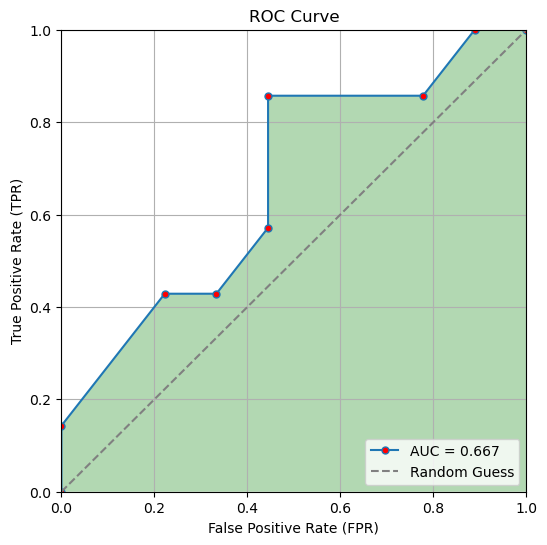

In [9]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# --------- True labels and model scores ---------
# You can pass either predicted probabilities or raw scores (they need not be in [0,1])
y_true = np.array([0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0])
y_score = np.array([0.2, 0.28, 0.1, 0.6, 0.5, 0.3, 0.6, 0.8, 
                    0.2, 0.25, 0.4, 0.2, 0.5, 0.3, 0.18, 0.18])

# --------- Compute FPR, TPR, and thresholds ---------
fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score)
print('\nThresholds:', thresholds)
print('FPR:', np.round(fpr, 3))
print('TPR:', np.round(tpr, 3))

# --------- Compute AUC ---------
roc_auc = metrics.auc(fpr, tpr)
print('AUC:', np.round(roc_auc, 3))

# --------- Plot ROC Curve ---------
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker='o', markerfacecolor='r', markersize=5, label=f'AUC = {roc_auc:.3f}')
plt.fill_between(fpr, 0, tpr, facecolor='green', alpha=0.3)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
